[✓] imports<br>
[✓] Dataset Download<br>
[✓] Augmentations<br>
[✓] DataLoader<br>
[✓] CNN Architecture class<br>
[✓] Loss Function<br>
[✓] Optimizer<br>
[✓] Scheduler<br>
[✓] Training Loop<br>
[✓] Evaluation Loop<br>
[✓] Model Save<br>
[✓] Model Load<br>
[✓] Inference Script<br>
[✓] Metrics Script<br>

[ ] Best Checkpoint Saving<br>
[ ] Training History<br>
[ ] Accuracy/Loss Plots<br>
[ ] Confusion Matrix<br>
[ ] Top-K Predictions<br>
[ ] README<br>

In [75]:
import torch
from torch import nn,save,load
from torchvision import datasets
from torch.optim import AdamW
from torch.utils.data import DataLoader
from tqdm import tqdm
from torchvision import transforms
from torch.optim.lr_scheduler import CosineAnnealingLR
from torchvision.transforms import  ToTensor, Compose

### We just define the transformation rules at the top but real tranformation occurs on the fly in each batch<br>
### The batch passes the image thru the train_transform function everytime before loading

In [76]:
train_dataset=datasets.CIFAR10("./data_cnn",download=True,train= True, transform=ToTensor())
test_dataset=datasets.CIFAR10("./data_cnn",download=True,train= False, transform=ToTensor())

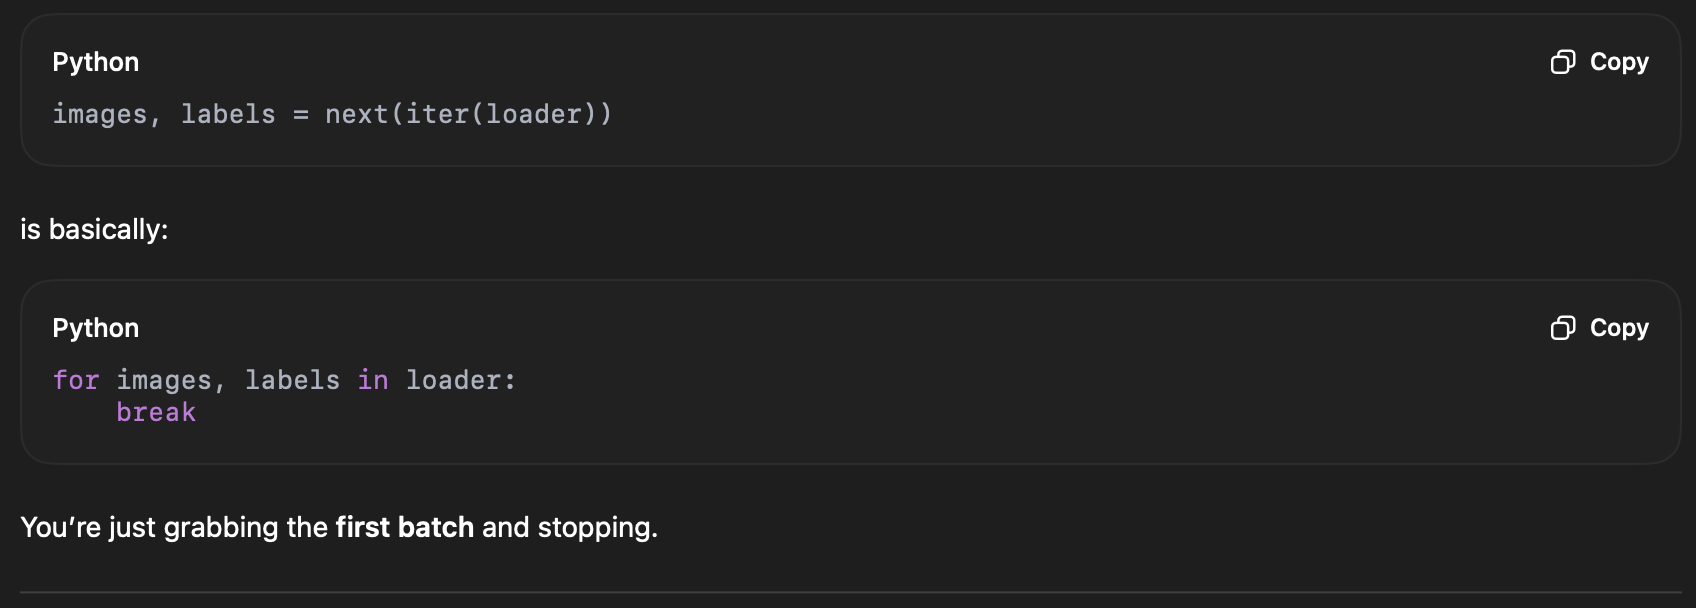

In [77]:
loader=DataLoader(train_dataset,batch_size=50000)
images,labels=next(iter(loader))      
#grabs the 1st batch that is the ONLY batch here and stops
mean=images.mean(dim=[0,2,3])
std=images.std(dim=[0,2,3])
#(images shape: ):      {B, C, H, W}
#   we want to keep the channels intact, i.e diff means and std devs accross each channel
#   so dim: (0,2,3): mean, std across all pics, all heights, all widths keeping Channels intact

In [78]:
mean

tensor([0.4914, 0.4822, 0.4465])

In [79]:
std

tensor([0.2470, 0.2435, 0.2616])

In [80]:
train_transform=Compose([
    transforms.RandomCrop(32,padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean,std)
])
test_transform= Compose([
    transforms.ToTensor(),
    transforms.Normalize(std,mean)
])

### WE KEEP SAME TRAIN MEAN , TRAIN STD for both train and test datasets

In [121]:
train_dataset=datasets.CIFAR10("./data_cnn",download=False,train= True, transform=train_transform)
test_dataset=datasets.CIFAR10("./data_cnn",download=False,train= True, transform=test_transform)

In [82]:
train_dataset

Dataset CIFAR10
    Number of datapoints: 50000
    Root location: ./data_cnn
    Split: Train
    StandardTransform
Transform: Compose(
               RandomCrop(size=(32, 32), padding=4)
               RandomHorizontalFlip(p=0.5)
               ToTensor()
               Normalize(mean=tensor([0.4914, 0.4822, 0.4465]), std=tensor([0.2470, 0.2435, 0.2616]))
           )

In [83]:
test_dataset

Dataset CIFAR10
    Number of datapoints: 50000
    Root location: ./data_cnn
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=tensor([0.2470, 0.2435, 0.2616]), std=tensor([0.4914, 0.4822, 0.4465]))
           )

In [ ]:
train=DataLoader(train_dataset, batch_size=128, shuffle=True)
test=DataLoader(test_dataset, batch_size=128, shuffle=False)

TypeError: __init__() got an unexpected keyword argument 'seed'

In [85]:
train

In [86]:
test

In [87]:
feature, label = next(iter(train))

In [88]:
feature

tensor([[[[-1.9892e+00, -1.9892e+00, -1.9892e+00,  ..., -1.9892e+00,
           -1.9892e+00, -1.9892e+00],
          [-1.9892e+00, -1.9892e+00, -1.9892e+00,  ..., -1.9892e+00,
           -1.9892e+00, -1.9892e+00],
          [-1.9892e+00, -1.9892e+00, -1.9892e+00,  ..., -1.9892e+00,
           -1.9892e+00, -1.9892e+00],
          ...,
          [-1.9733e+00, -1.9733e+00, -1.9575e+00,  ..., -1.9892e+00,
           -1.9892e+00, -1.9892e+00],
          [-1.9575e+00, -1.9257e+00, -1.9575e+00,  ..., -1.9892e+00,
           -1.9892e+00, -1.9892e+00],
          [-1.9416e+00, -1.9098e+00, -1.9098e+00,  ..., -1.9892e+00,
           -1.9892e+00, -1.9892e+00]],

         [[-1.9802e+00, -1.9802e+00, -1.9802e+00,  ..., -1.9802e+00,
           -1.9802e+00, -1.9802e+00],
          [-1.9802e+00, -1.9802e+00, -1.9802e+00,  ..., -1.9802e+00,
           -1.9802e+00, -1.9802e+00],
          [-1.9802e+00, -1.9802e+00, -1.9802e+00,  ..., -1.9802e+00,
           -1.9802e+00, -1.9802e+00],
          ...,
     

In [89]:
label

tensor([3, 2, 7, 7, 9, 0, 9, 2, 2, 8, 1, 4, 0, 2, 8, 5, 2, 6, 6, 0, 0, 9, 4, 8,
        3, 5, 1, 8, 8, 2, 5, 3, 7, 5, 7, 2, 8, 0, 2, 0, 2, 1, 6, 4, 2, 0, 6, 7,
        2, 3, 7, 9, 7, 4, 7, 2, 0, 9, 3, 5, 2, 0, 8, 8, 1, 0, 9, 7, 8, 6, 6, 0,
        7, 3, 9, 5, 0, 5, 3, 3, 9, 9, 7, 7, 2, 5, 9, 7, 7, 7, 4, 5, 3, 1, 1, 5,
        8, 0, 9, 6, 7, 2, 0, 1, 4, 8, 0, 8, 8, 4, 2, 1, 3, 4, 0, 1, 9, 4, 5, 1,
        8, 3, 1, 3, 3, 3, 5, 2])

In [90]:
feature.shape

torch.Size([128, 3, 32, 32])

In [91]:
label.shape

torch.Size([128])

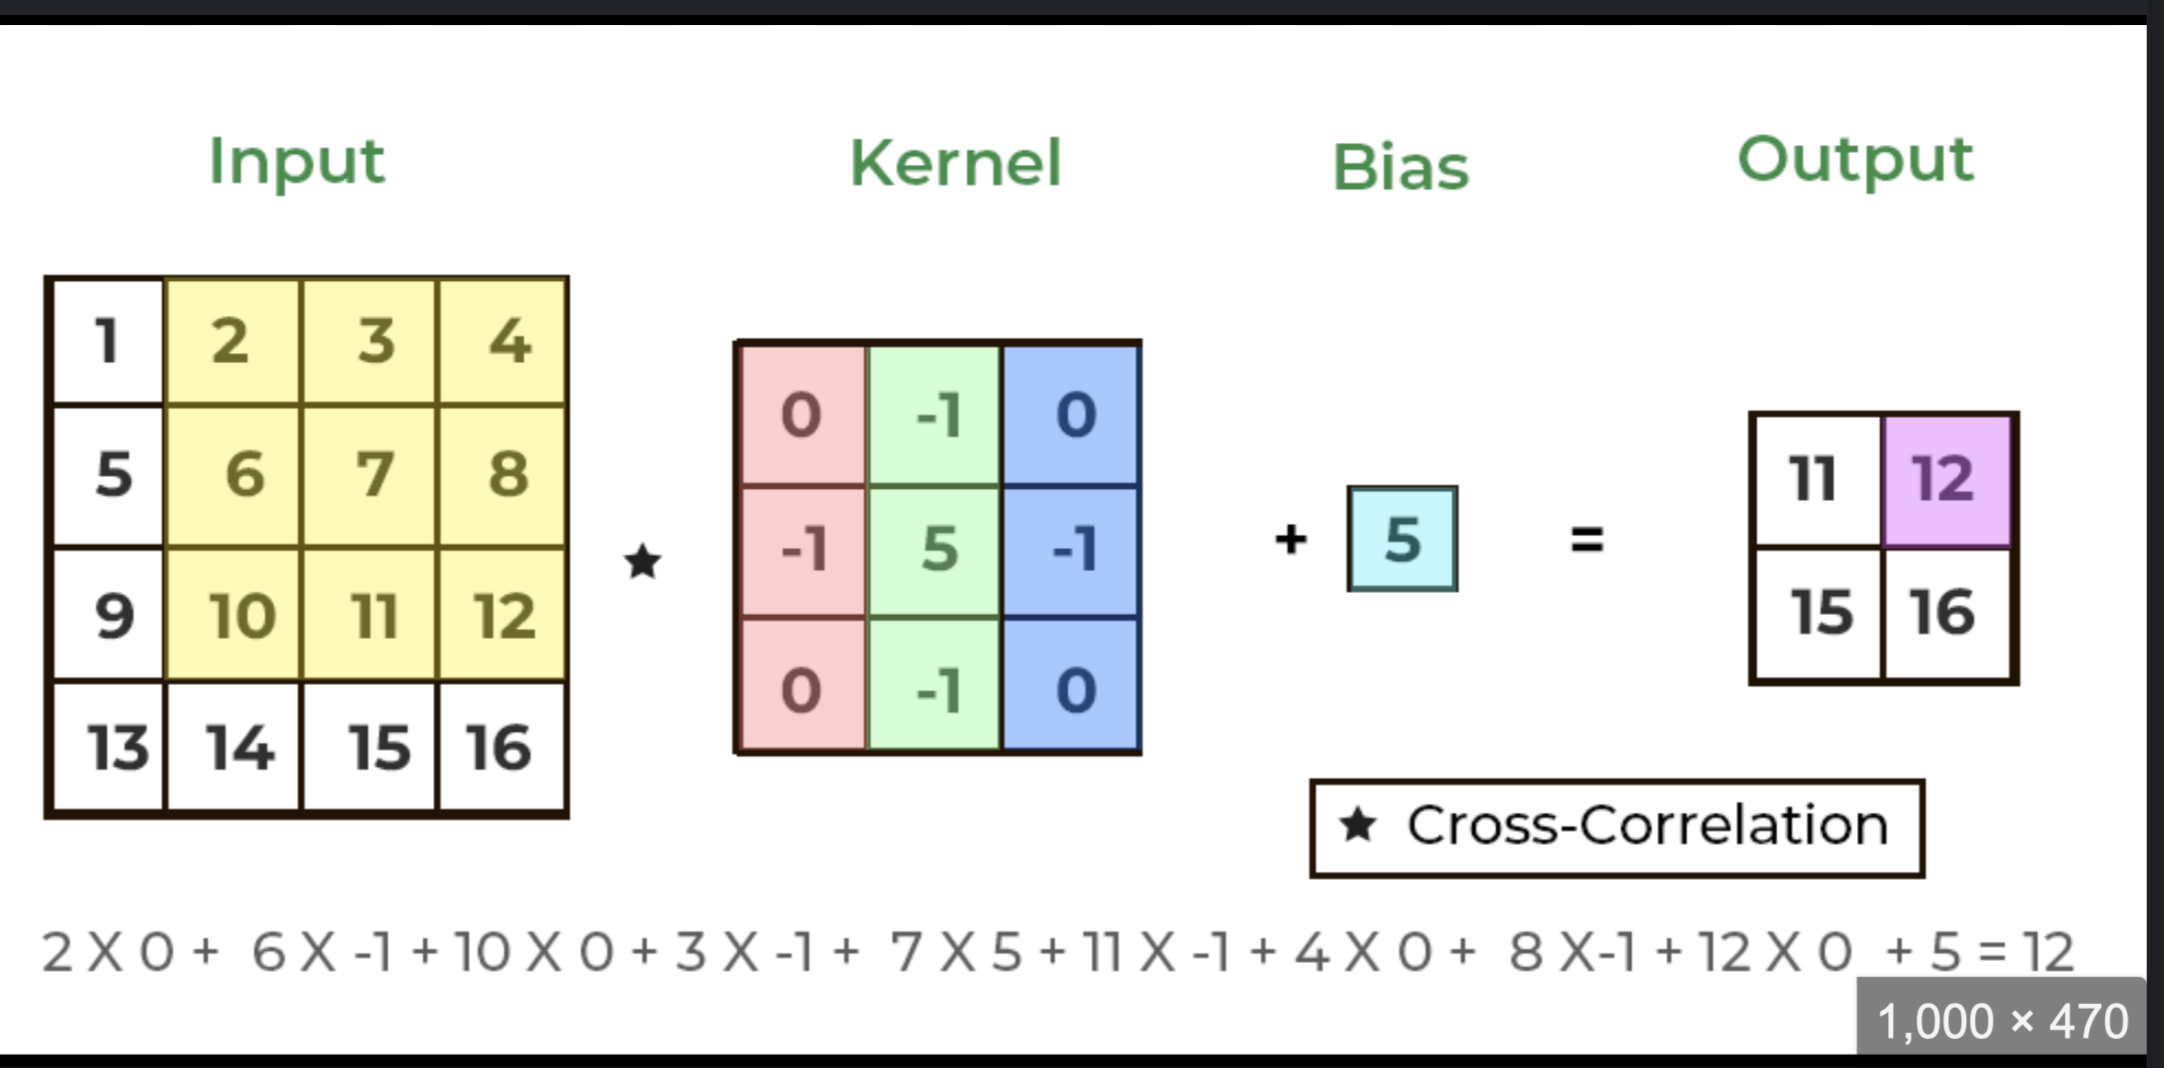

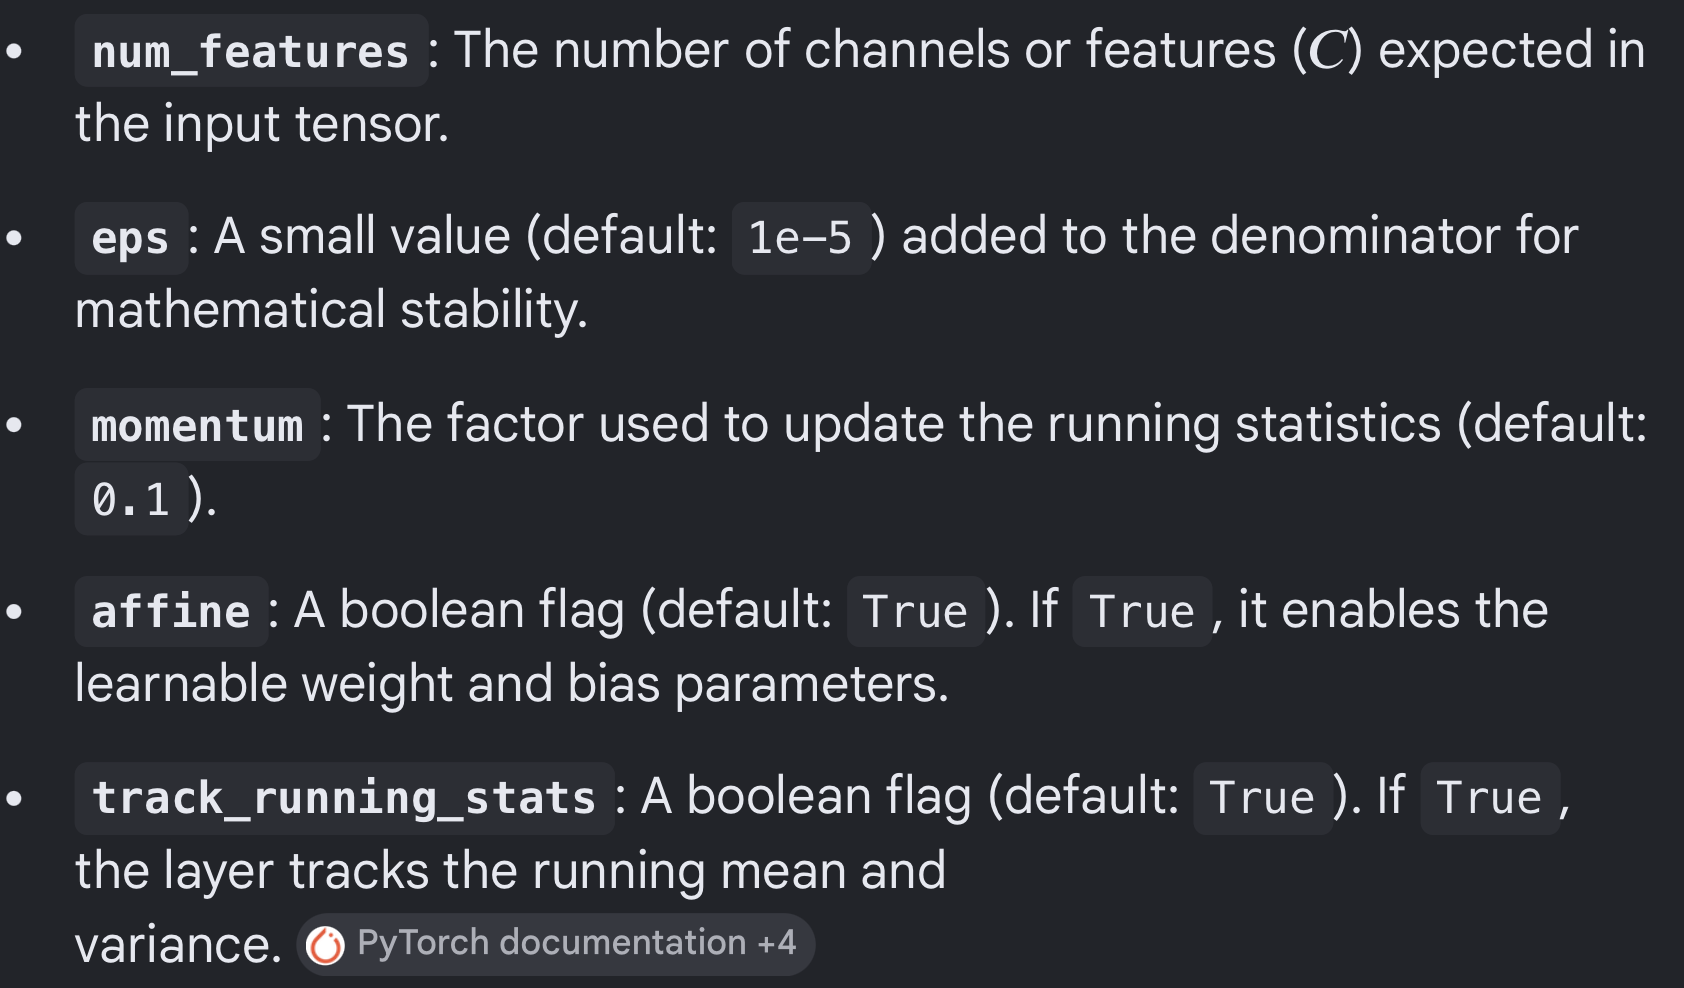

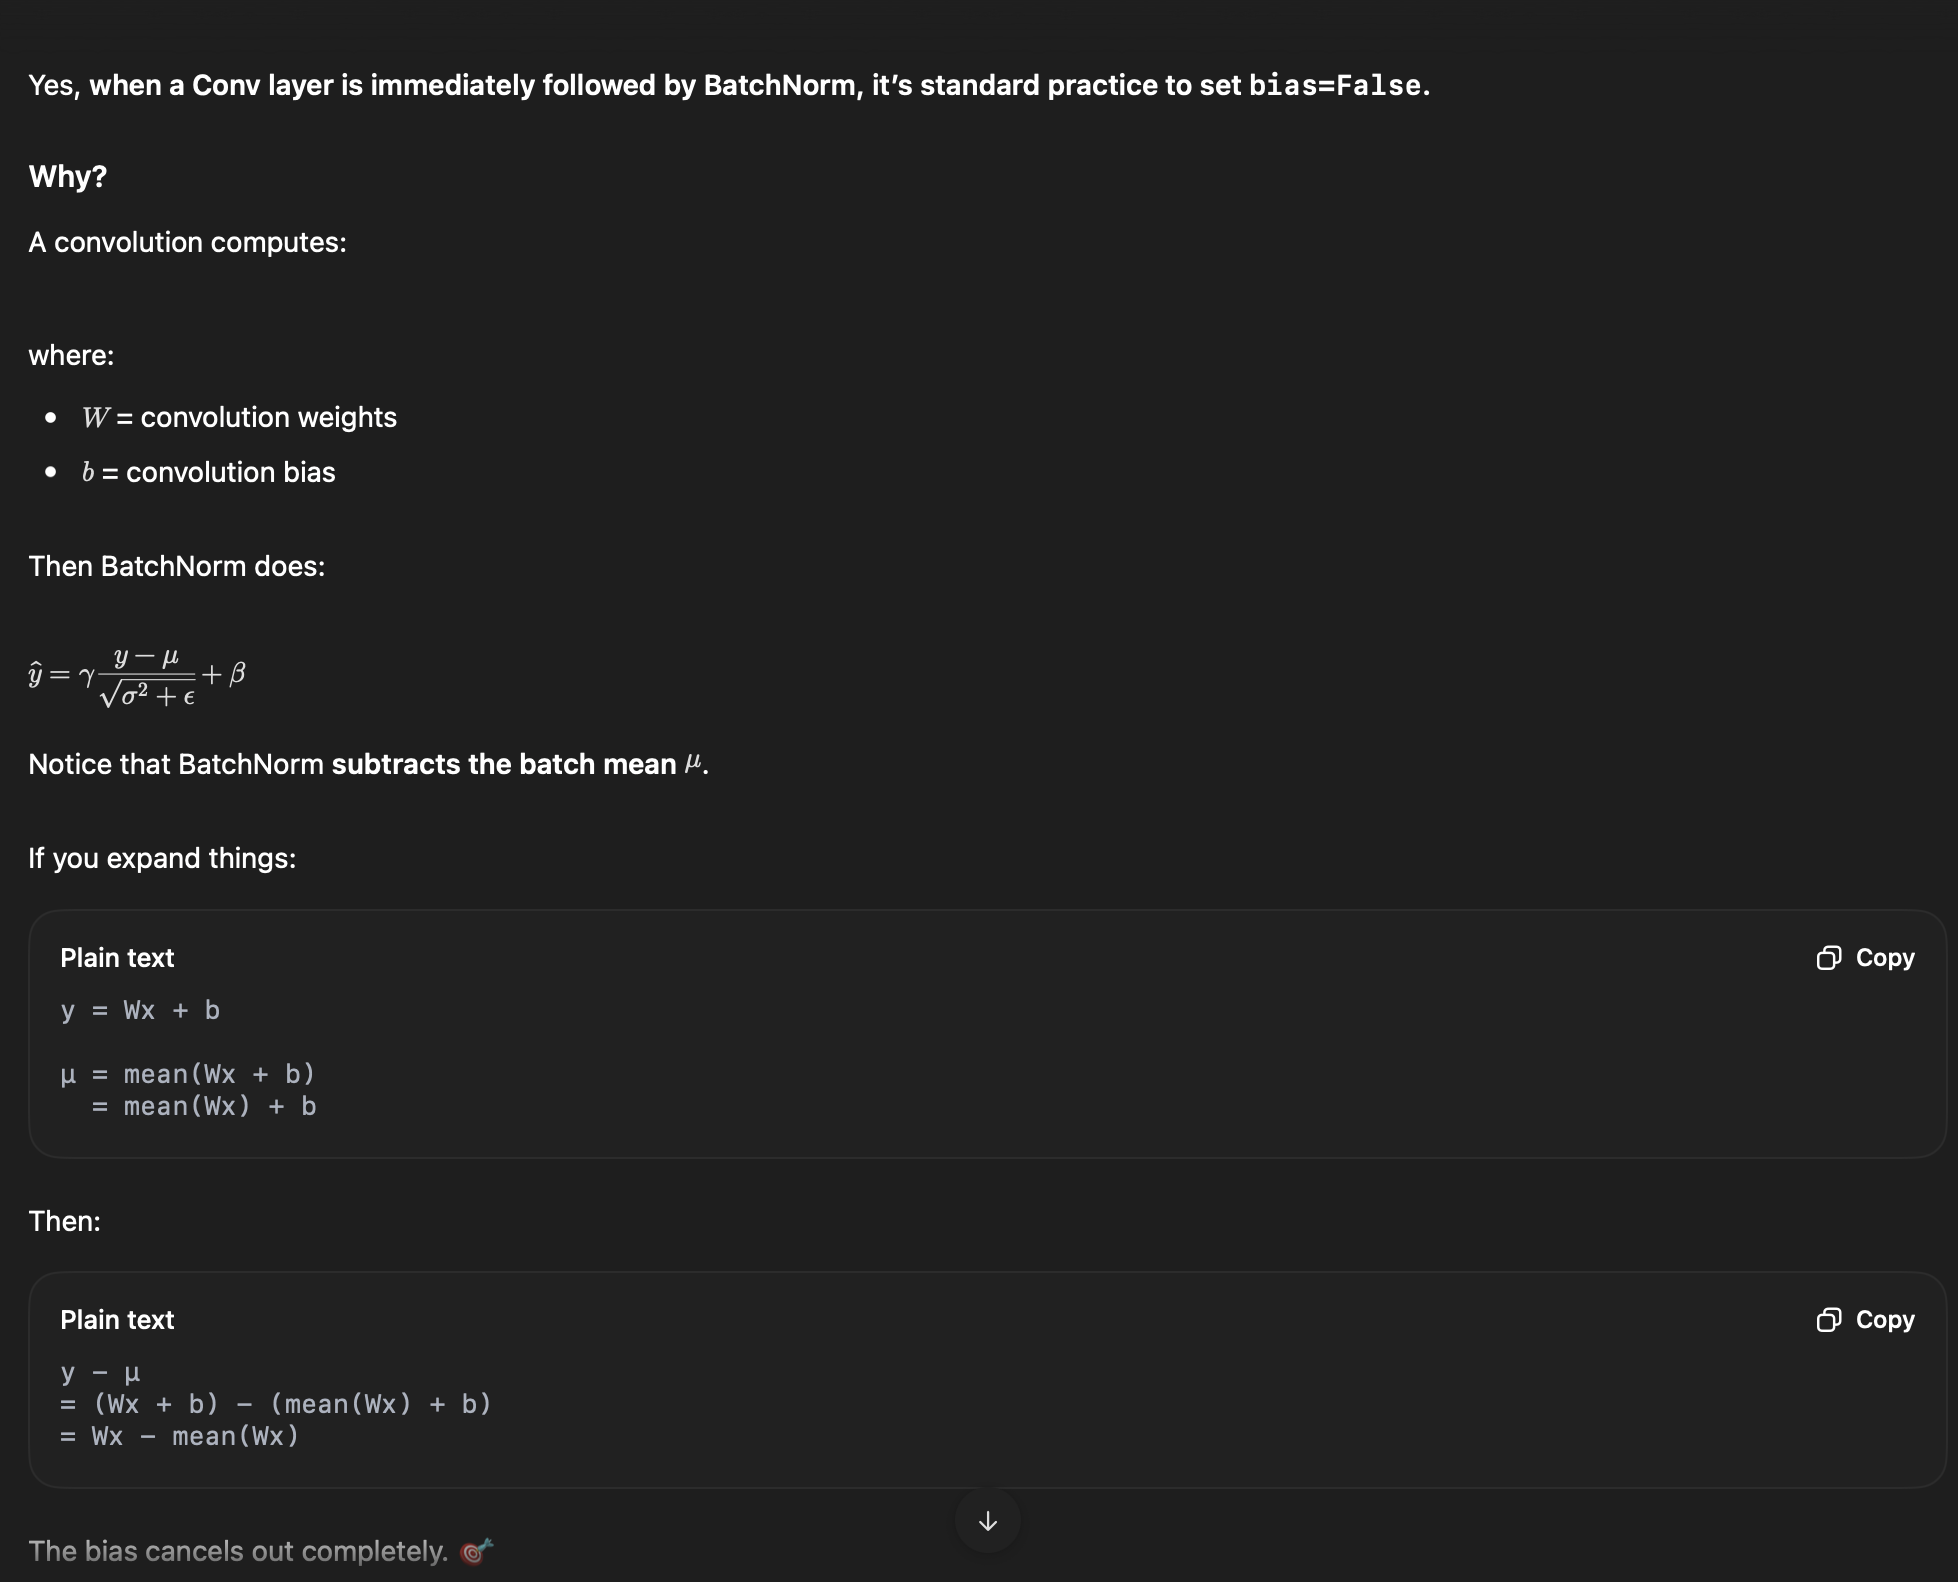

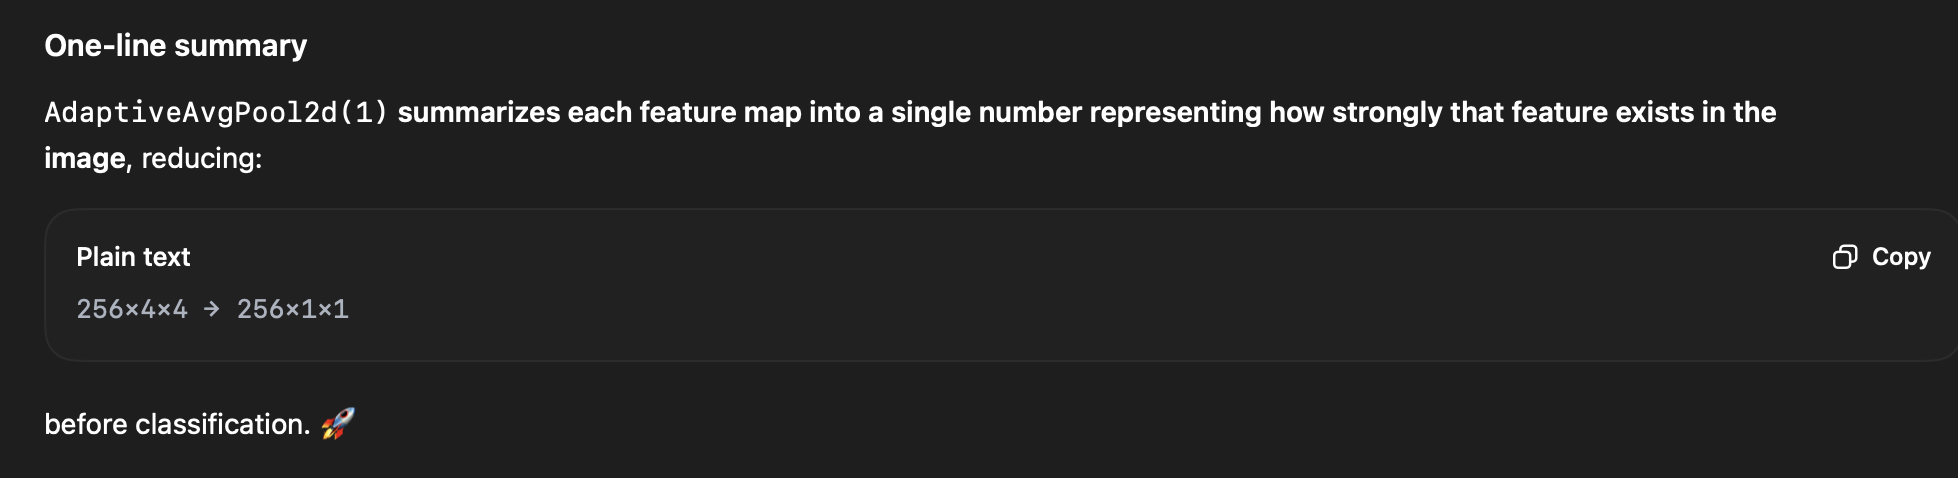

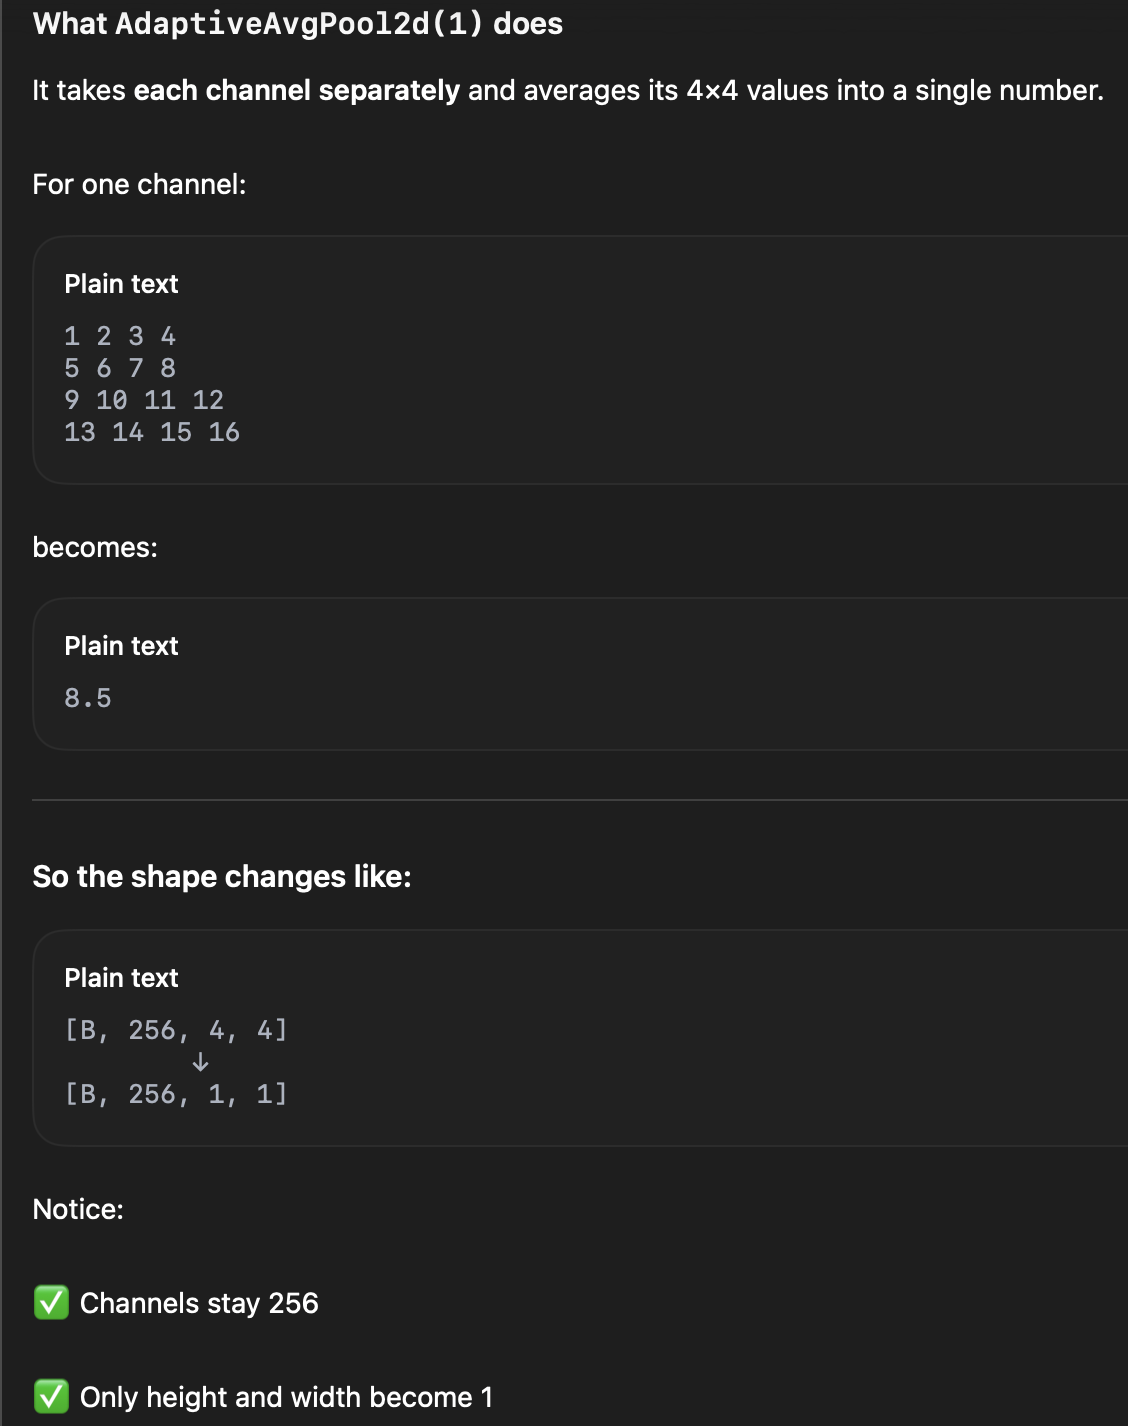

In [92]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.model=nn.Sequential(
            #Block 1
            nn.Conv2d(3,64,3,1,1,bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),#modifis the tensor no new tensor returned
            nn.Conv2d(64,64,3,1,1,bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.25),

            #Block 2
            nn.Conv2d(64,128,3,1,1,bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),#modifis the tensor no new tensor returned
            nn.Conv2d(128,128,3,1,1,bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.25),
            
            #Block 3
            nn.Conv2d(128,256,3,1,1,bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),#modifis the tensor no new tensor returned
            nn.Conv2d(256,256,3,1,1,bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            
            nn.AdaptiveAvgPool2d(1),

            nn.Flatten(),
            nn.Dropout(0.5),

            nn.Linear(256,10)
            
        )
    def forward(self,x):
        return self.model(x)

In [93]:
VGG_style=CNN()

In [94]:
VGG_style

CNN(
  (model): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.25, inplace=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (12): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU(inplace=True)
    (14): MaxPool2d(ke

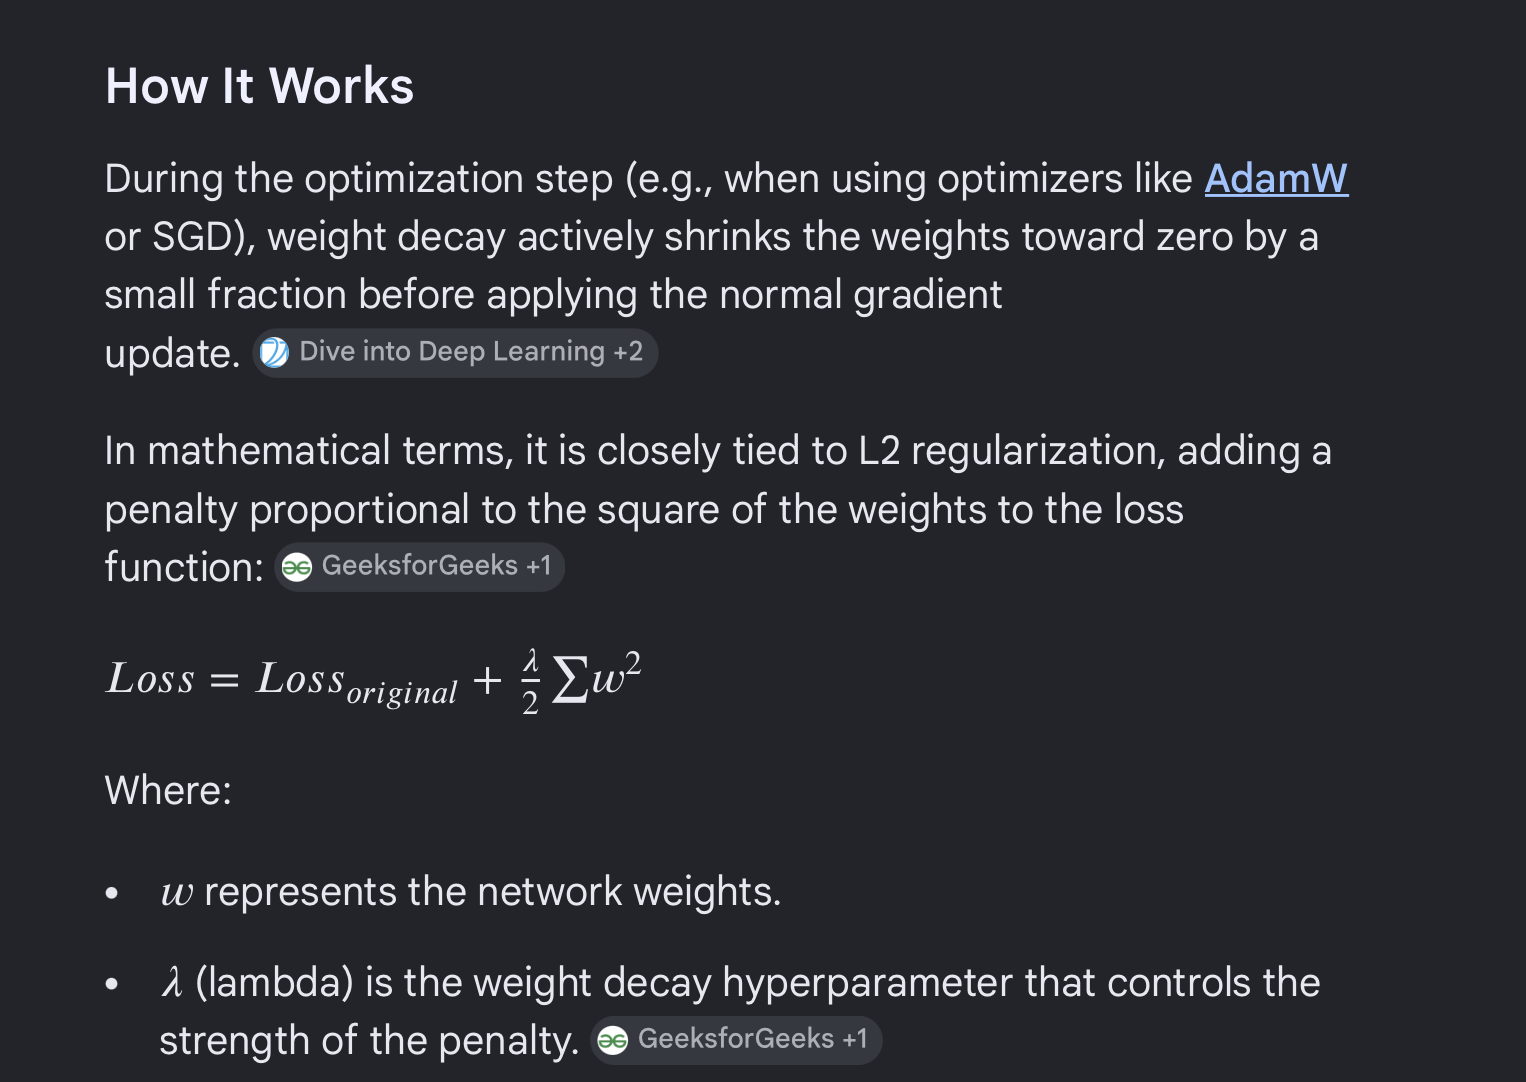

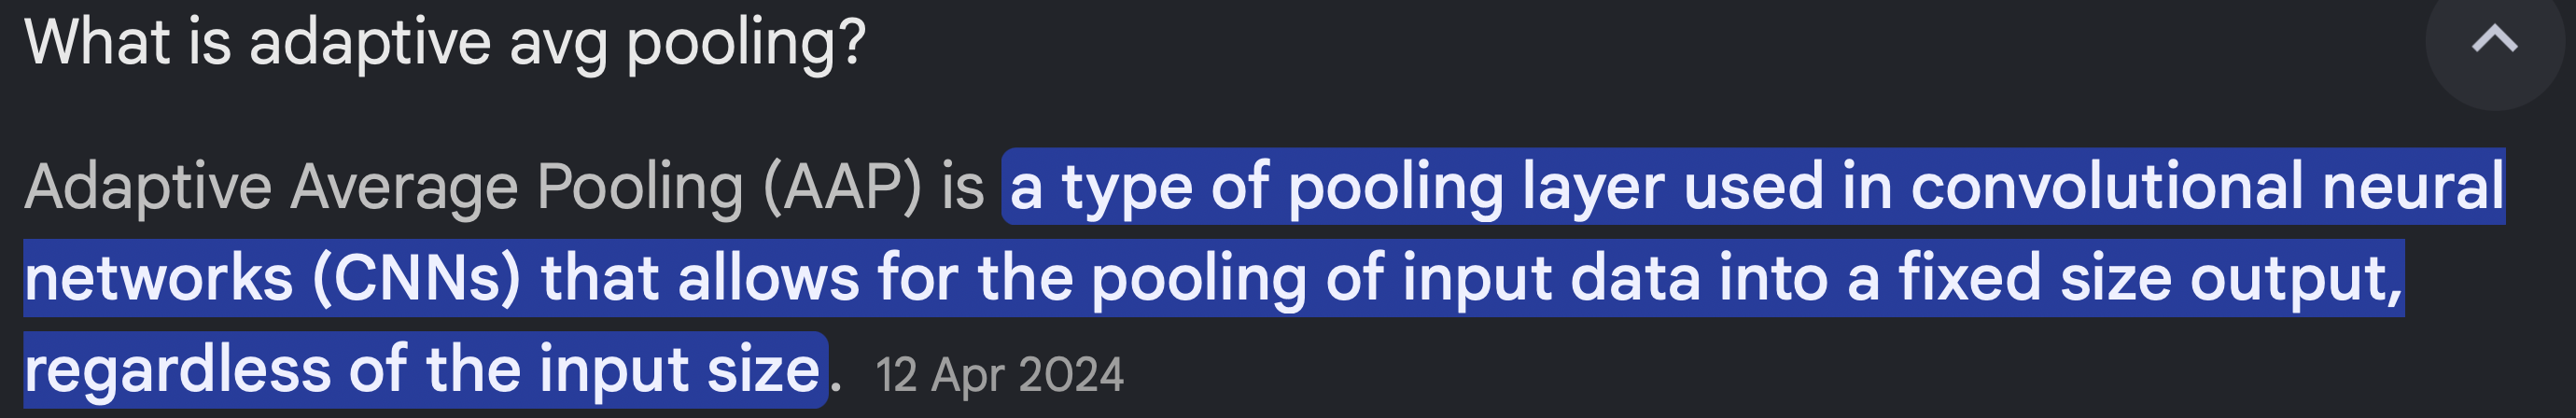

## Cosine annealing LR schedular:<br>
### ensures gradual fall of lr


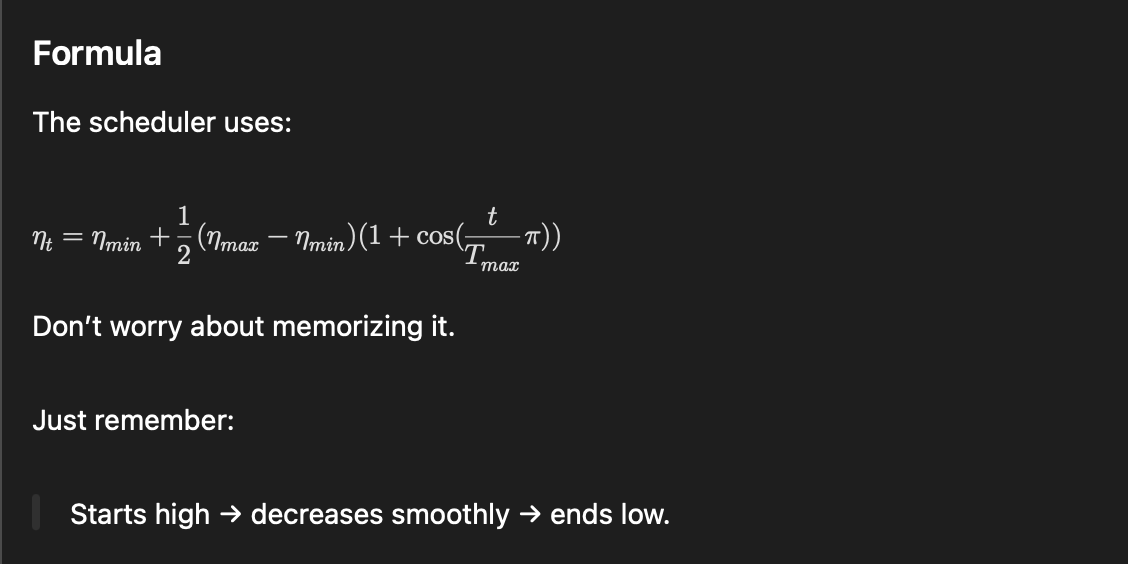

In [95]:
epochs=100

In [96]:
loss=nn.CrossEntropyLoss()
optim= AdamW(VGG_style.parameters(),lr=3e-4,weight_decay=1e-4)
schedular=CosineAnnealingLR(optim,T_max=epochs)

In [97]:
device=torch.device('mps')

In [98]:
device

device(type='mps')

In [99]:
VGG_style.to(device)

CNN(
  (model): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.25, inplace=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (12): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU(inplace=True)
    (14): MaxPool2d(ke

### adaptive avg pool 2D (output_size) returns output_size number of planes for any given input planes

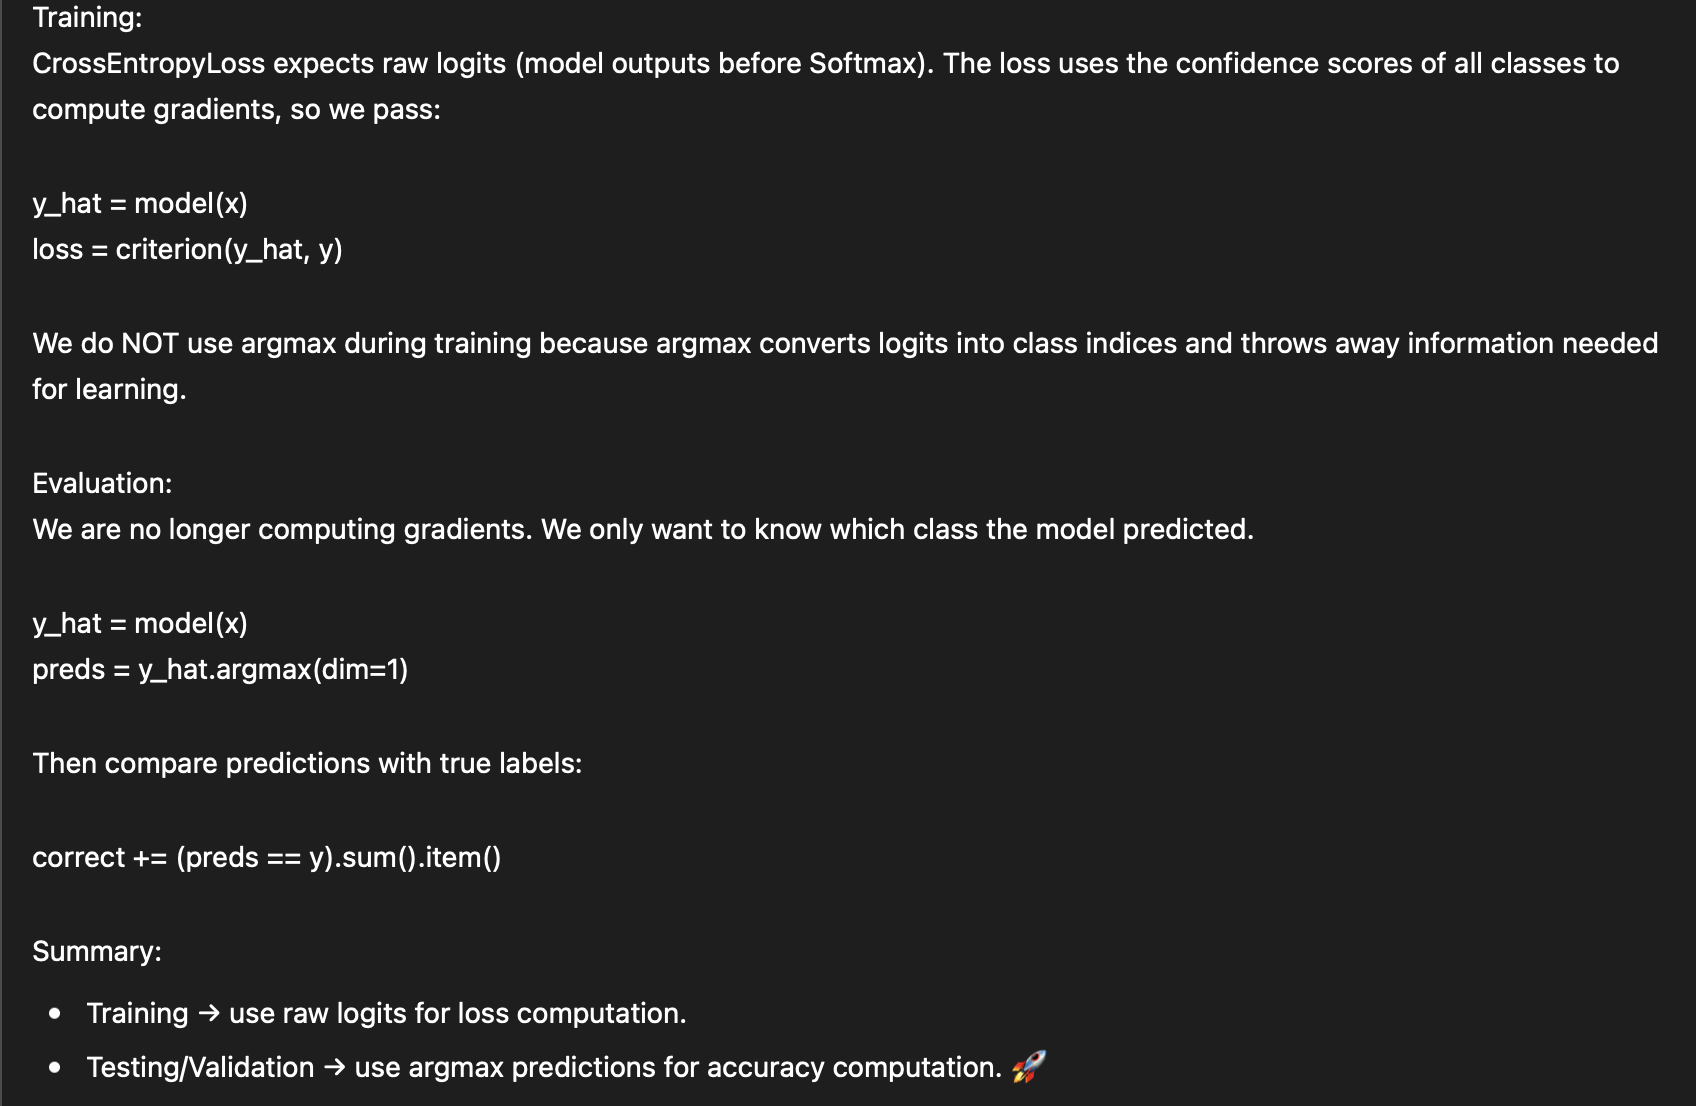

## training loop

In [107]:
VGG_style.train()
for epoch in tqdm(range(epochs)):
    epoch_loss=0.0
    for batch in train:
        x,y= batch
        x=x.to(device)
        y=y.to(device)
        y_hat=VGG_style.forward(x)
        L=loss(y_hat,y)
        optim.zero_grad()
        L.backward()
        optim.step()
        epoch_loss+=L.item()
    print(f"Loss at epoch number:  {epoch+1} : {epoch_loss}")
    schedular.step()    # updates the LR in the optim

  0%|          | 0/100 [00:02<?, ?it/s]


KeyboardInterrupt: 

## testing loop

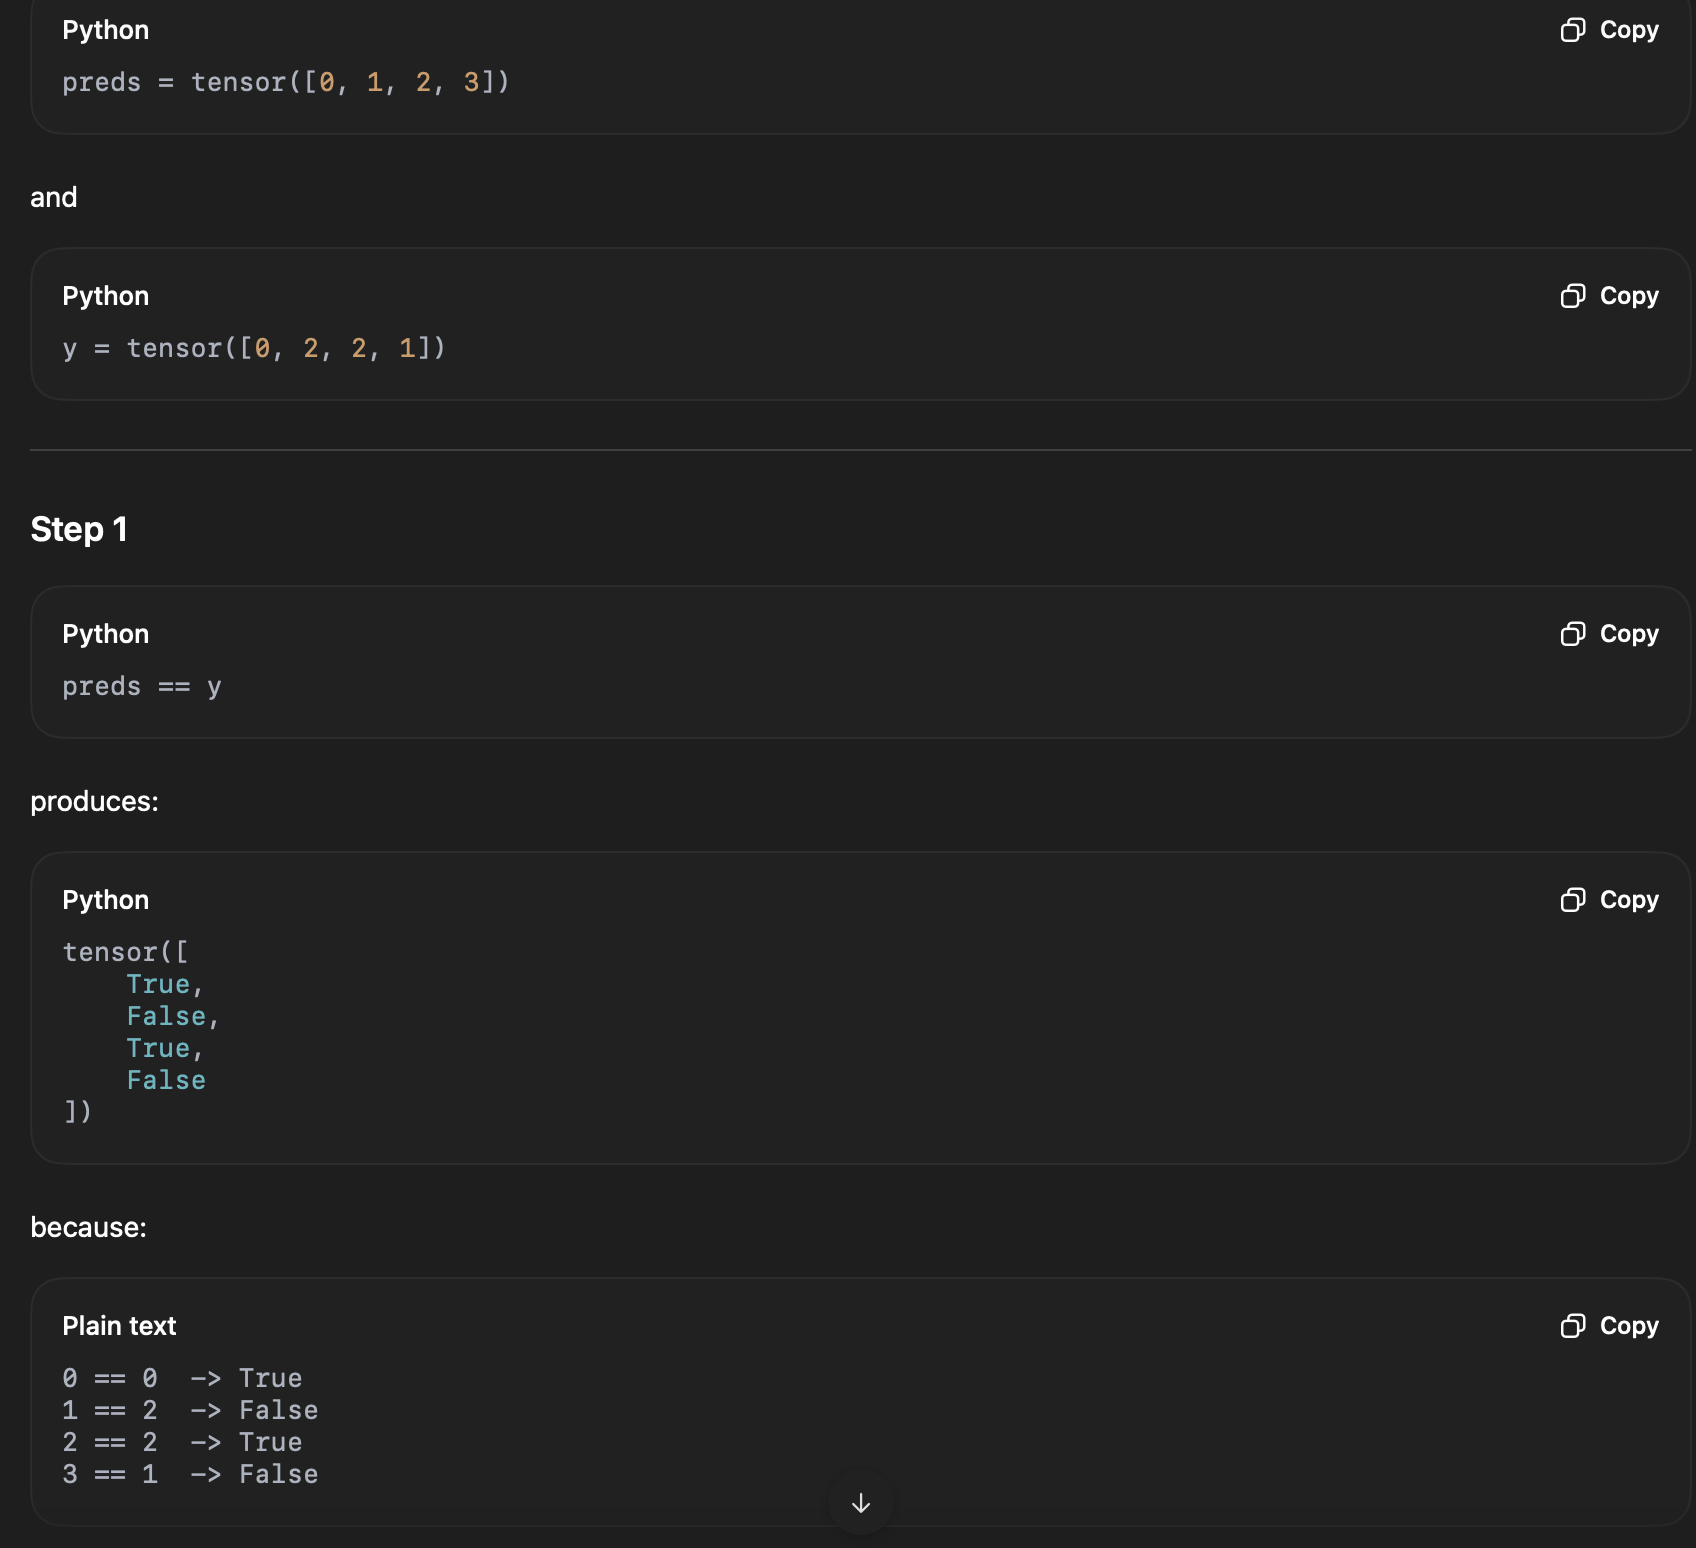

In [106]:
VGG_style.eval()
correct=0
total=0
with torch.no_grad():
    for batch in test:
        x,y= batch
        x=x.to(device)
        y=y.to(device)
        y_hat=VGG_style(x)
        pred=y_hat.argmax(dim=1)
        correct+=(pred==y).sum().item()
        total+=y.size(0)
print(f"accuracy: {correct/len(test)*100}")
        

KeyboardInterrupt: 

## Model save

In [102]:
with open("vgg_net_type_cifar.pt",'wb') as f:
    save(VGG_style,f)

## Model Load

In [103]:
model= torch.load("vgg_net_type_cifar.pt", weights_only=False)
model.eval()

CNN(
  (model): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.25, inplace=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (12): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU(inplace=True)
    (14): MaxPool2d(ke

### Inference Script

In [110]:
import zipfile as zf
zip_path="/Users/par_04/code_playground/ml/ML_Dataset/CIFAR_TEST.zip"
extract_path="."
with zf.ZipFile(zip_path,'r') as F:
    F.extractall(extract_path)

In [116]:
from PIL import Image
import torch
from pathlib import Path

In [117]:
classes=["airplane", "automobile", "bird", "cat ","deer", "dog", "frog", "horse", "ship", "truck"]

In [118]:
model.eval()

CNN(
  (model): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.25, inplace=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (12): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU(inplace=True)
    (14): MaxPool2d(ke

In [112]:
transform_pipeline=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

In [ ]:
folder="/Users/par_04/code_playground/projects/scene-understanding/notebooks/CIFAR_TEST"
image_paths= Path(folder).glob("*")   # list of all image paths of images inside folder
with torch.no_grad():
    for path in image_paths:
        image=Image.open(path).convert("RGB")   #renders the image
        x= transform_pipeline(image)# makes it into a Tensor and normalizes
        x=x.unsqueze(0)# adds a new dimension at 0th posn
        x=x.to(device)
        y_hat=model(x)
        probs=torch.softmax(y_hat,dim=1)# convert logits to probab
        confidence=probs.argmax().item()*100
        pred=y_hat.argmax(dim=1).item()
        print(f"{path.name}")   # file name
        print(f"{classes[pred]}")
        print(f"conf: {confidence}")


AttributeError: 'list' object has no attribute 'read'

### Metrics Script